# 自注意力

## 基础知识

自注意力是来源于自己，每个 x 是 key\value\query

卷积神经网络和自注意力都拥有并行计算的优势， 而且自注意力的最大路径长度最短。 

但是因为其计算复杂度是关于序列长度的二次方，所以在很长的序列中计算会非常慢。

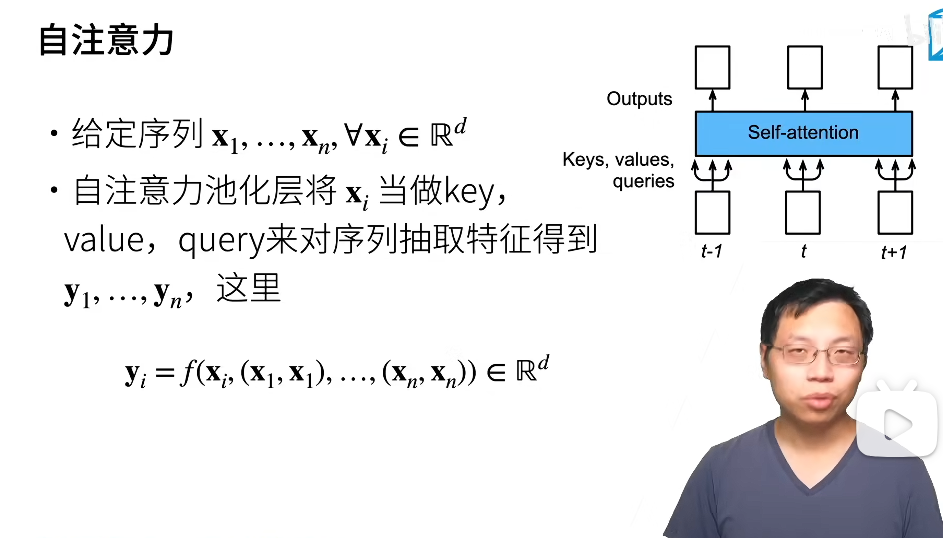

架构对比：目标都是将由 n 个词元组成的序列映射到另一个长度相等的序列，其中的每个输入词元或输出词元都由 d 维向量表示。k是卷积核大小。

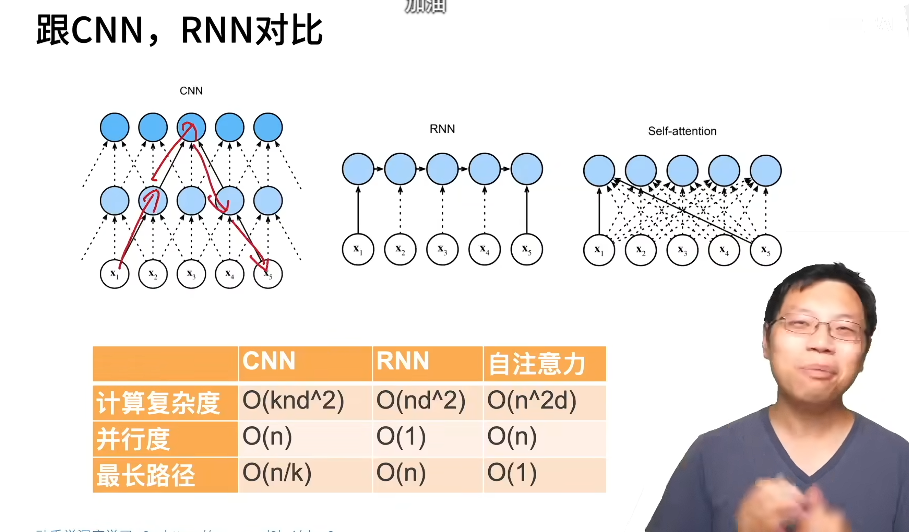

- **并行度**表示每个输出 $y_i$ 可以同时计算，而不需要先算出前一个y才能接着算后一个y
- **路径长度**决定了前向传播时，远距离词之间的信息要经过多少层传递。路径越长，梯度消失风险越大，依赖越难建立。对应于计算机视觉中的感受野的概念

Transformer选择了一条“以平方复杂度换取完美全局视野和极致并行”的技术路线

卷积神经网络和自注意力都拥有并行计算的优势， 而且自注意力的最大路径长度最短。 

但是因为其计算复杂度是关于序列长度的二次方，所以在很长的序列中计算会非常慢。

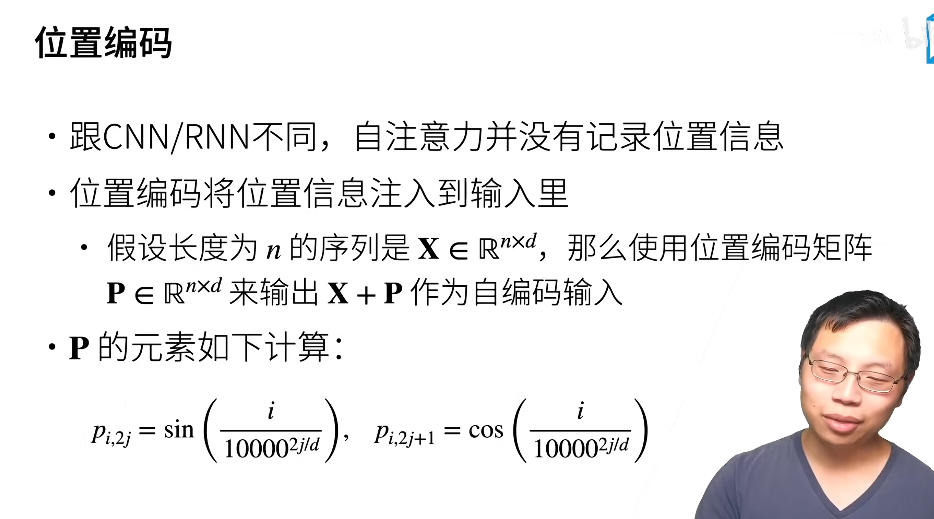

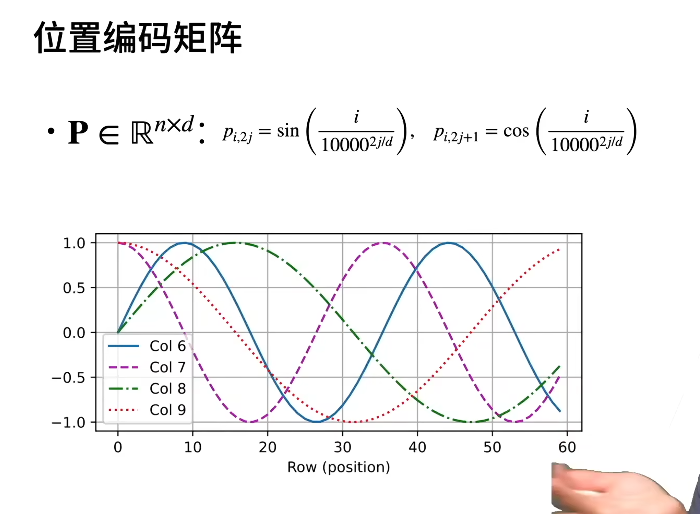

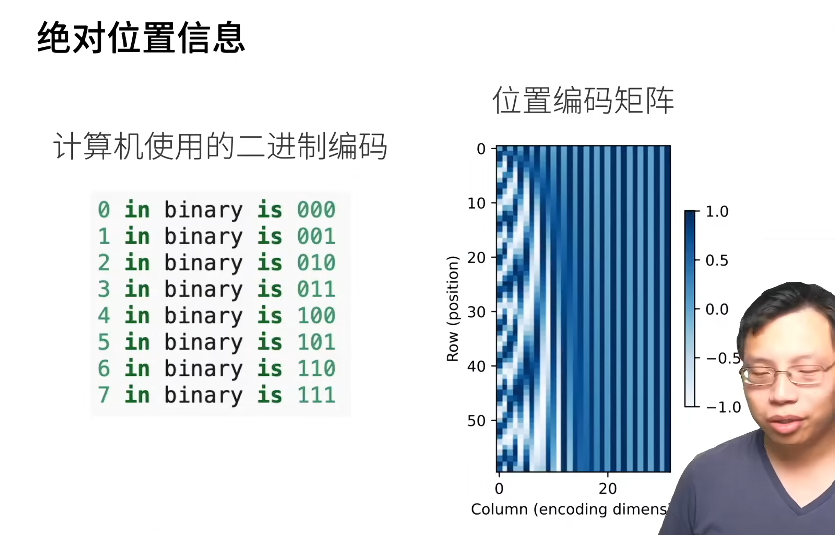

每行是一个样本，每列是对于编码，越往后变化越慢

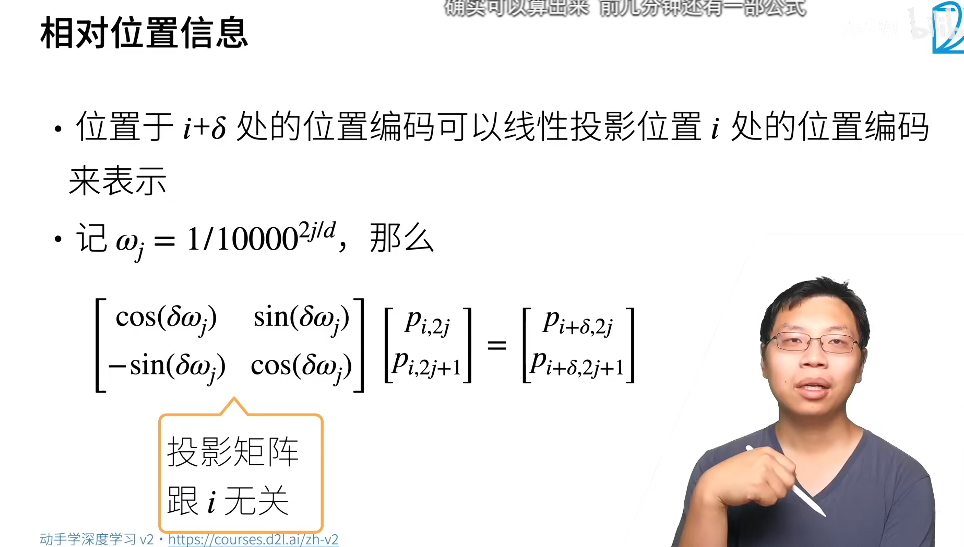

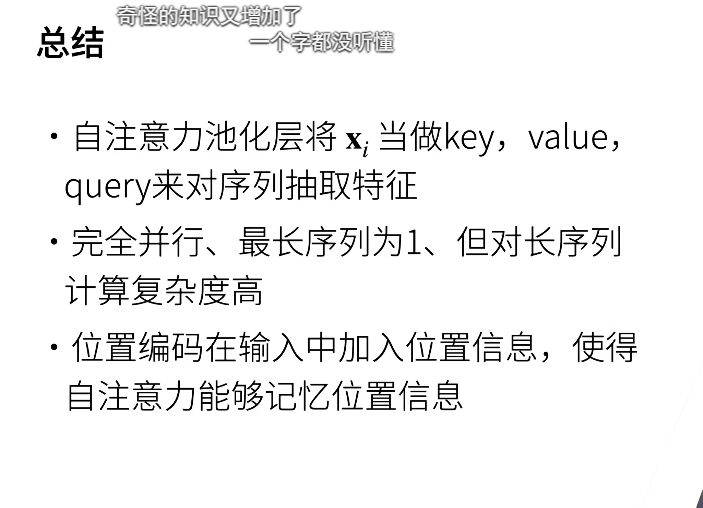

## 代码

In [1]:
import math
import torch
from torch import nn
from d2l import torch as d2l

In [2]:
num_hiddens, num_heads = 100, 5
attention = d2l.MultiHeadAttention(num_hiddens, num_hiddens, num_hiddens,
                                   num_hiddens, num_heads, 0.5)
attention.eval()

MultiHeadAttention(
  (attention): DotProductAttention(
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (W_q): Linear(in_features=100, out_features=100, bias=False)
  (W_k): Linear(in_features=100, out_features=100, bias=False)
  (W_v): Linear(in_features=100, out_features=100, bias=False)
  (W_o): Linear(in_features=100, out_features=100, bias=False)
)

In [3]:
batch_size, num_queries, valid_lens = 2, 4, torch.tensor([3, 2])
X = torch.ones((batch_size, num_queries, num_hiddens))
attention(X, X, X, valid_lens).shape

torch.Size([2, 4, 100])

In [4]:
#@save
class PositionalEncoding(nn.Module):
    """位置编码"""
    def __init__(self, num_hiddens, dropout, max_len=1000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(dropout)
        # 创建一个足够长的P
        self.P = torch.zeros((1, max_len, num_hiddens))
        X = torch.arange(max_len, dtype=torch.float32).reshape(
            -1, 1) / torch.pow(10000, torch.arange(
            0, num_hiddens, 2, dtype=torch.float32) / num_hiddens)
        self.P[:, :, 0::2] = torch.sin(X)
        self.P[:, :, 1::2] = torch.cos(X)

    def forward(self, X):
        X = X + self.P[:, :X.shape[1], :].to(X.device)
        return self.dropout(X)

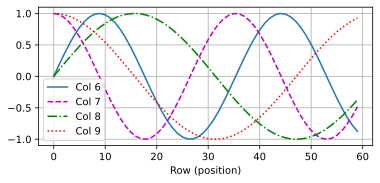

In [5]:
encoding_dim, num_steps = 32, 60
pos_encoding = PositionalEncoding(encoding_dim, 0)
pos_encoding.eval()
X = pos_encoding(torch.zeros((1, num_steps, encoding_dim)))
P = pos_encoding.P[:, :X.shape[1], :]
d2l.plot(torch.arange(num_steps), P[0, :, 6:10].T, xlabel='Row (position)',
         figsize=(6, 2.5), legend=["Col %d" % d for d in torch.arange(6, 10)])

In [6]:
for i in range(8):
    print(f'{i}的二进制是：{i:>03b}')

0的二进制是：000
1的二进制是：001
2的二进制是：010
3的二进制是：011
4的二进制是：100
5的二进制是：101
6的二进制是：110
7的二进制是：111


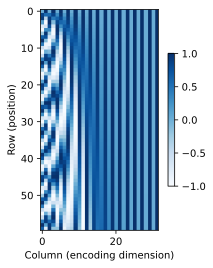

In [7]:
P = P[0, :, :].unsqueeze(0).unsqueeze(0)
d2l.show_heatmaps(P, xlabel='Column (encoding dimension)',
                  ylabel='Row (position)', figsize=(3.5, 4), cmap='Blues')